# Data Understanding: CMAPSS Dataset

This notebook covers the initial exploration and understanding of the CMAPSS (Commercial Modular Aero-Propulsion System Simulation) dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")

# Define columns based on dataset documentation
columns = ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
columns += [f'sensor_{i}' for i in range(1, 22)]

# Load one of the sub-datasets (FD001) as an example for exploration
data_path = '../data/raw/CMAPSS/'
train_df = pd.read_csv(os.path.join(data_path, 'train_FD001.txt'), sep='\\s+', header=None, names=columns)
test_df = pd.read_csv(os.path.join(data_path, 'test_FD001.txt'), sep='\\s+', header=None, names=columns)
rul_df = pd.read_csv(os.path.join(data_path, 'RUL_FD001.txt'), sep='\\s+', header=None, names=['RUL'])

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"RUL shape: {rul_df.shape}")
train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Dataset Explained

The CMAPSS dataset consists of multiple multivariate time series. Each dataset (FD001, FD002, FD003, FD004) has different operating conditions and fault modes.
- **train_FD00X.txt**: Run-to-failure data for multiple engines.
- **test_FD00X.txt**: Data for engines that haven't failed yet (truncated series).
- **RUL_FD00X.txt**: The actual Remaining Useful Life (RUL) for the engines in the test set.

Each row represents a snapshot of data taken during a single operational cycle.

## Features Understood

The features include:
- **unit_number**: Engine ID.
- **time_cycles**: The operational cycle number.
- **op_setting_1, op_setting_2, op_setting_3**: Operating conditions.
- **sensor_1 to sensor_21**: Sensor measurements (e.g., temperature, pressure, speed).

In [2]:
# Let's check summary statistics
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


## Data Quality Checked

We need to check for missing values, constant features (which provide no information), and duplicates.

In [3]:
# Check for missing values
missing_values = train_df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Check for constant features (zero variance)
nunique = train_df.nunique()
constant_features = nunique[nunique == 1].index.tolist()
print(f"\nConstant features (can be dropped): {constant_features}")

# Check for duplicates
print(f"\nDuplicate rows: {train_df.duplicated().sum()}")

Missing values per column:
 Series([], dtype: int64)

Constant features (can be dropped): ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Duplicate rows: 0


## Sensor Distributions Examined

Let's visualize the distributions of the sensor readings to understand their scales and variations.

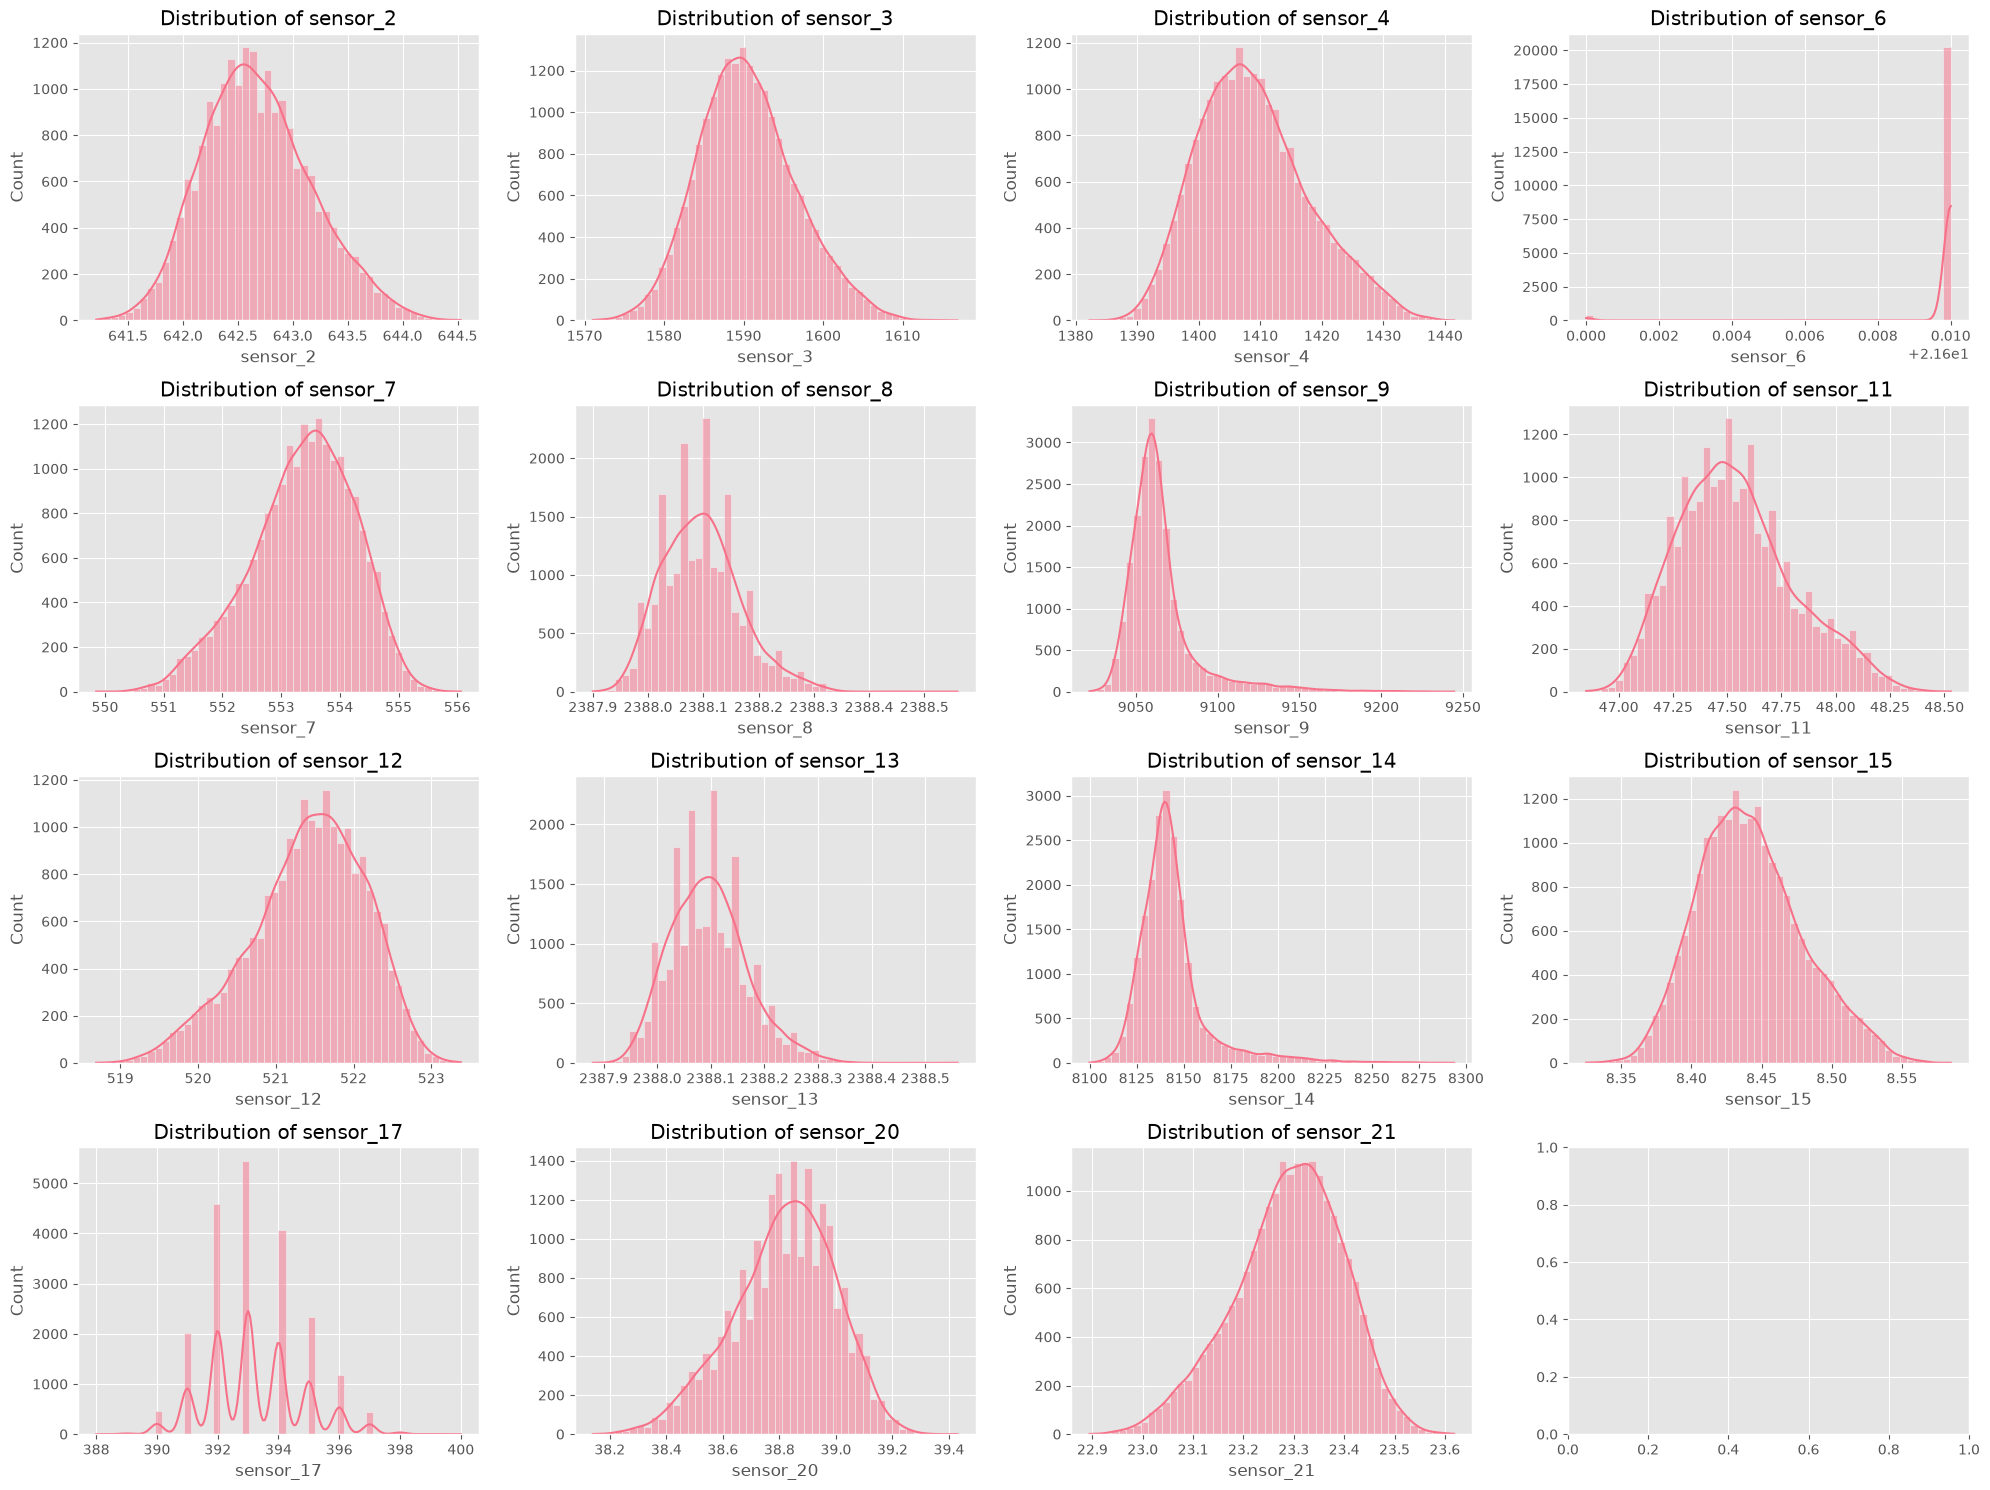

In [4]:
# Plot distributions of sensors, excluding constant features
active_sensors = [col for col in train_df.columns if 'sensor' in col and col not in constant_features]

fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

for i, sensor in enumerate(active_sensors[:16]):
    sns.histplot(train_df[sensor], ax=axes[i], bins=50, kde=True)
    axes[i].set_title(f'Distribution of {sensor}')
    
plt.tight_layout()
plt.show()

## Engine Degradation Visualized

To see how sensors change over time (cycles) as an engine degrades, let's plot the sensor trajectories for a specific engine (e.g., engine 1).

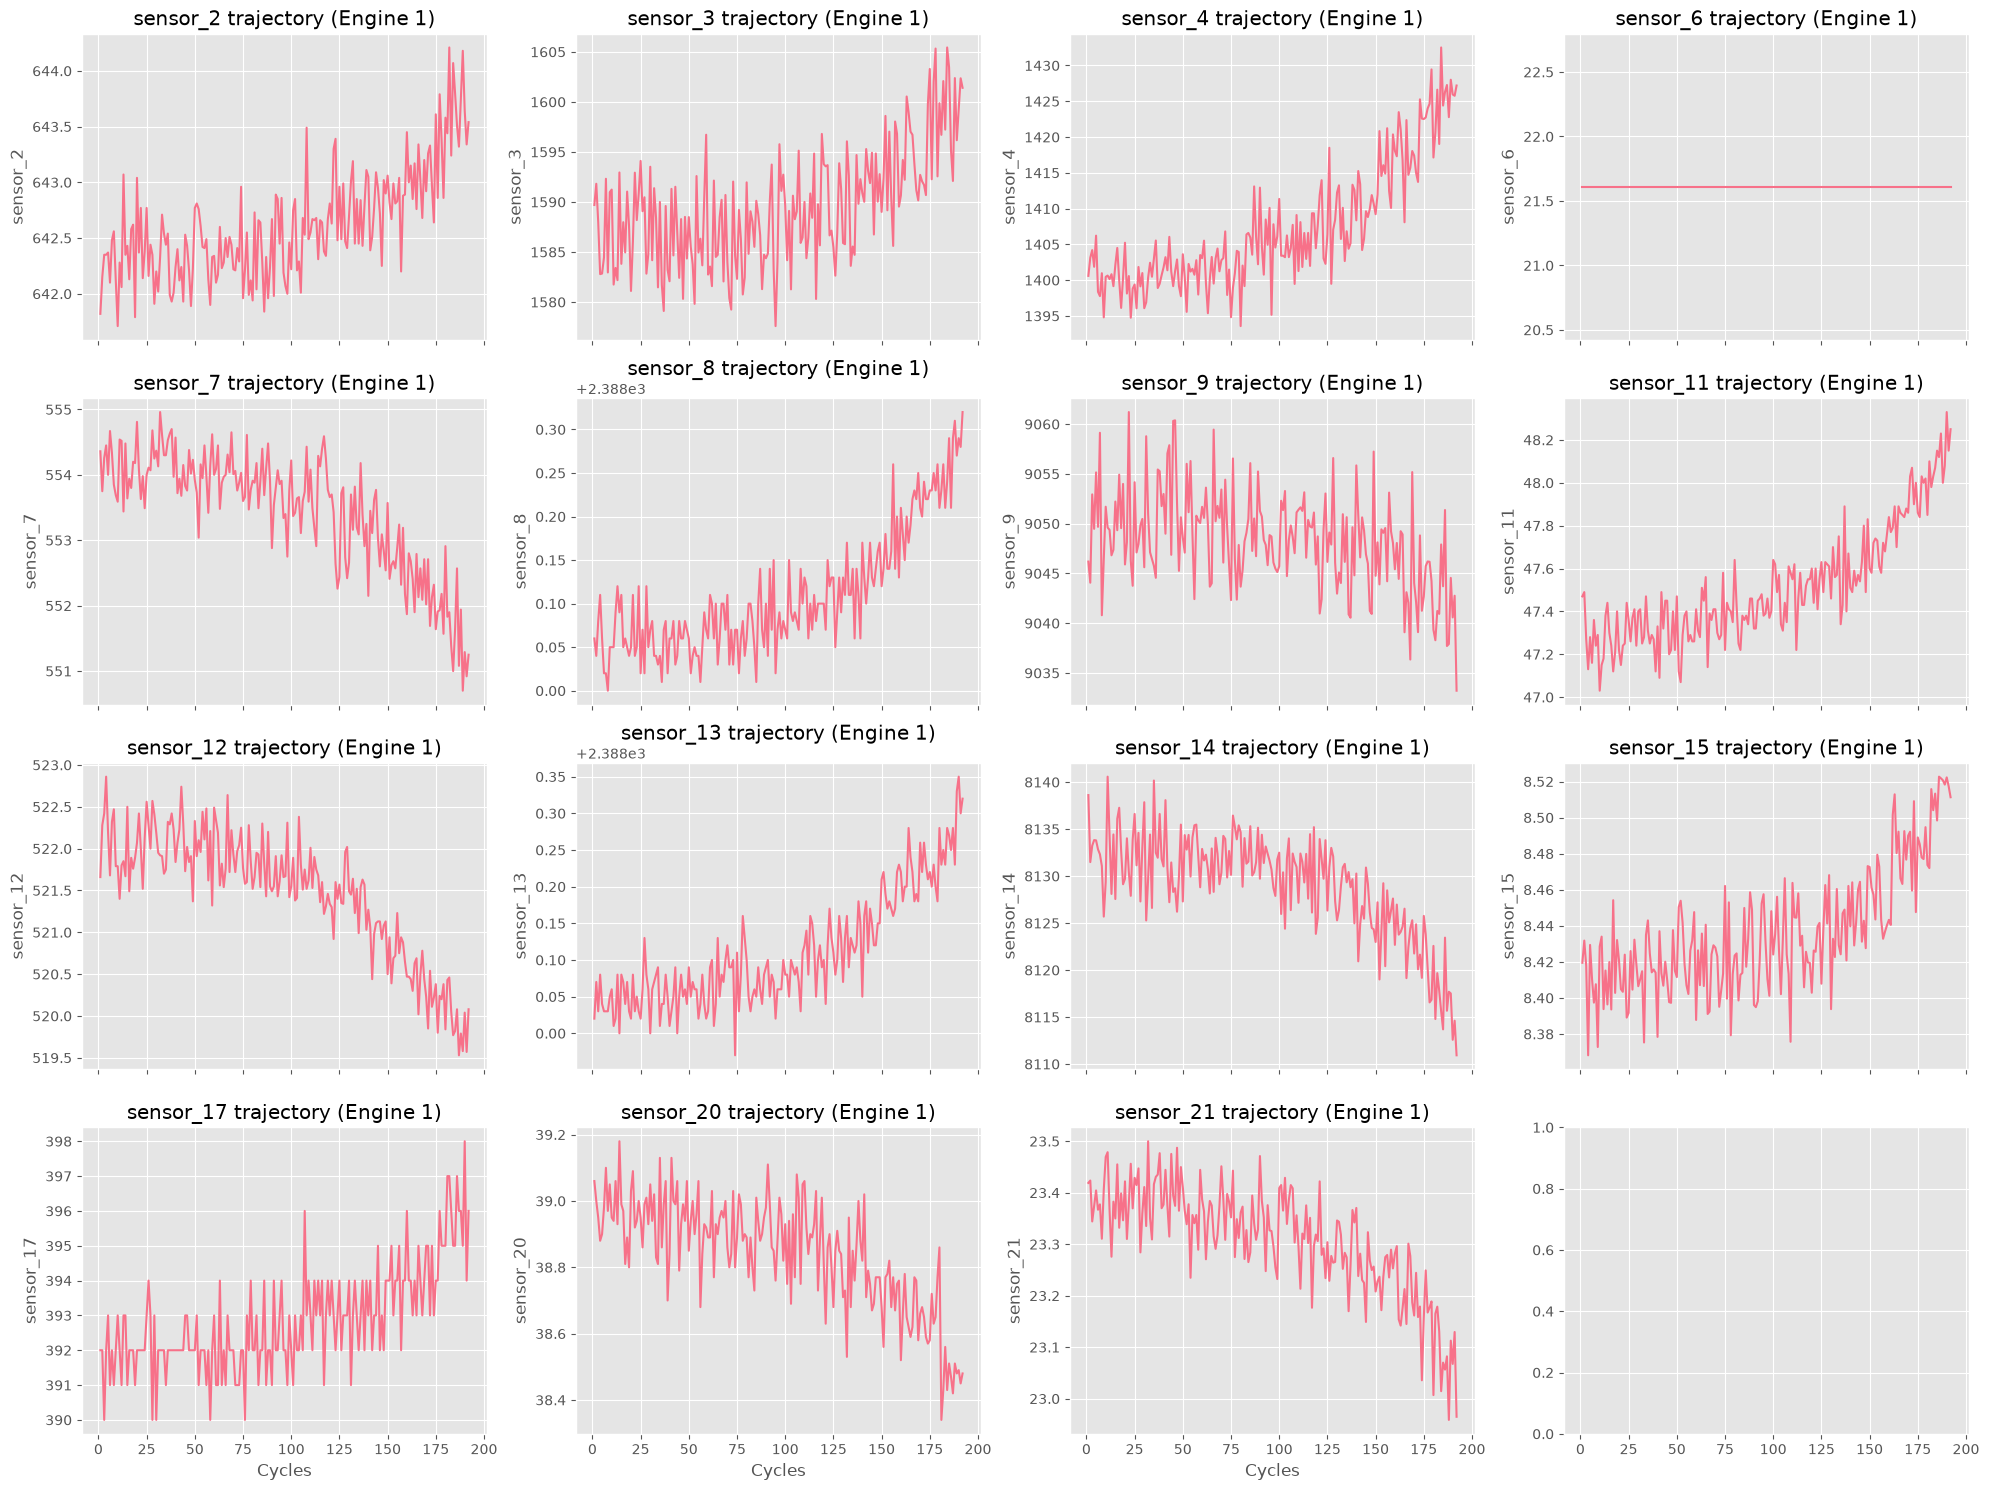

In [5]:
# Filter data for engine 1
engine_1_data = train_df[train_df['unit_number'] == 1]

fig, axes = plt.subplots(4, 4, figsize=(20, 15), sharex=True)
axes = axes.flatten()

for i, sensor in enumerate(active_sensors[:16]):
    sns.lineplot(data=engine_1_data, x='time_cycles', y=sensor, ax=axes[i])
    axes[i].set_title(f'{sensor} trajectory (Engine 1)')
    axes[i].set_xlabel('Cycles')
    
plt.tight_layout()
plt.show()

## RUL Target Understood

The target variable for predictive maintenance is Remaining Useful Life (RUL). In the training set, engines are run to failure. We can calculate the true RUL for every cycle as the total cycles minus the current cycle.

Often, a piecewise linear RUL is used (capping the maximum RUL) because very early in the engine's life, degradation hasn't started and predicting exact time to failure is impossible and unnecessary.

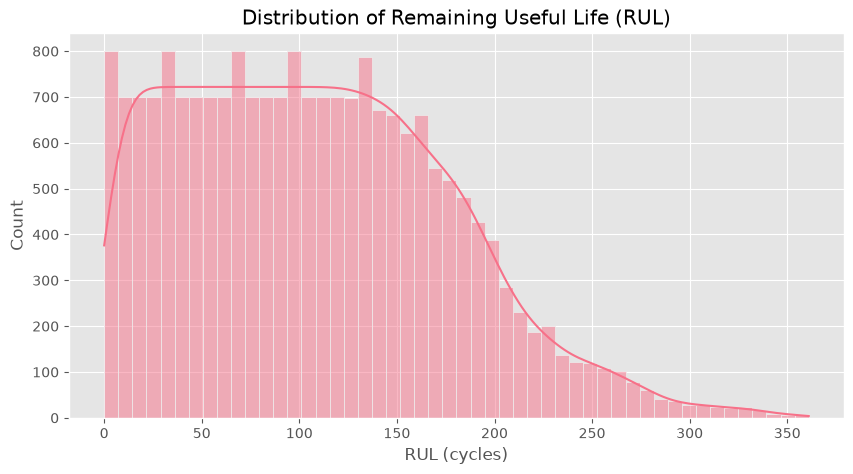

In [6]:
# Calculate linear RUL for training data
def add_rul(df):
    # Get the maximum cycle for each unit
    max_cycles = df.groupby('unit_number')['time_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_time_cycles']
    
    # Merge back to original dataframe
    merged = df.merge(max_cycles, on='unit_number', how='left')
    
    # Calculate RUL
    merged['RUL'] = merged['max_time_cycles'] - merged['time_cycles']
    merged.drop('max_time_cycles', axis=1, inplace=True)
    return merged

train_df = add_rul(train_df)

# Plot RUL distribution
plt.figure(figsize=(10, 5))
sns.histplot(train_df['RUL'], bins=50, kde=True)
plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('RUL (cycles)')
plt.show()

## Temporal Split Strategy Defined

For time-series and predictive maintenance data, it's crucial not to leak future data into the past. We use a **Grouped/Stratified Split** or a **Temporal Split**.
- Since data is partitioned by `unit_number` (engine), we must split by engine, not by random rows.
- For example, Engines 1-80 can be training, and Engines 81-100 can be validation.
- The CMAPSS dataset already provides a separate test set (`test_FD00X.txt`) with engines completely disjoint from the train set.

Our strategy will be to group by `unit_number` and use standard cross-validation strategies like `GroupKFold` to ensure entire engine trajectories remain together.

In [7]:
# Example of how we might define a simple train/val split by unit
units = train_df['unit_number'].unique()
np.random.seed(42)
val_units = np.random.choice(units, size=int(len(units)*0.2), replace=False)

val_df = train_df[train_df['unit_number'].isin(val_units)]
train_split_df = train_df[~train_df['unit_number'].isin(val_units)]

print(f"Validation Units: {len(val_units)}")
print(f"Train Units: {len(units) - len(val_units)}")

Validation Units: 20
Train Units: 80


### Processed Data Export

We will save a sample of the processed data to the `data/processed/` directory for the next stage.

In [8]:
# Save to processed data directory
processed_path = '../data/processed/'
os.makedirs(processed_path, exist_ok=True)

train_df.to_csv(os.path.join(processed_path, 'train_FD001_processed.csv'), index=False)
test_df.to_csv(os.path.join(processed_path, 'test_FD001_processed.csv'), index=False)
rul_df.to_csv(os.path.join(processed_path, 'RUL_FD001_processed.csv'), index=False)

print("Processed data saved to data/processed/")

Processed data saved to data/processed/
